In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import geopandas as gpd

In [2]:
df = pd.read_csv("Crime_Data_from_2020_to_Present.csv",nrows=5000)
print(df.head())
print(df.info())

       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0  190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130     7   
1  200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800     1   
2  200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700     3   
3  200907217  05/10/2023 12:00:00 AM  03/10/2020 12:00:00 AM      2037     9   
4  220614831  08/18/2022 12:00:00 AM  08/17/2020 12:00:00 AM      1200     6   

   AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0   Wilshire          784         1     510   
1    Central          182         1     330   
2  Southwest          356         1     480   
3   Van Nuys          964         1     343   
4  Hollywood          666         2     354   

                                Crm Cd Desc  ... Status   Status Desc  \
0                          VEHICLE - STOLEN  ...     AA  Adult Arrest   
1                     BURGLARY FROM VEHICLE  ...     IC   Invest Cont   
2                

In [ ]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors='coerce')
df = df.dropna(subset=['LAT', 'LON'])
df = df[(df['LAT'] != 0) & (df['LON'] != 0)]
df = df[(df['LAT'] > -90) & (df['LAT'] < 90)]
df = df[(df['LON'] > -180) & (df['LON'] < 180)]

C:\Users\hp\AppData\Local\Temp\ipykernel_16084\552854252.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
C:\Users\hp\AppData\Local\Temp\ipykernel_16084\552854252.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors='coerce')


In [ ]:

coords = df[['LAT', 'LON']].values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

In [ ]:

db = DBSCAN(eps=0.05, min_samples=10)
df['cluster'] = db.fit_predict(coords_scaled)
print(df['cluster'].value_counts())

cluster
 0     1840
-1     1817
 8       98
 3       76
 2       69
 9       62
 7       58
 5       53
 12      44
 10      42
 4       38
 6       36
 19      34
 16      31
 31      31
 34      27
 35      26
 39      26
 14      25
 13      25
 23      25
 46      23
 26      20
 44      20
 17      19
 33      19
 25      19
 11      19
 15      19
 30      19
 48      17
 21      17
 20      16
 27      16
 38      15
 49      13
 18      13
 24      13
 32      12
 41      12
 1       12
 29      12
 37      11
 47      11
 28      11
 36      11
 55      11
 52      11
 56      10
 22      10
 54      10
 43      10
 50      10
 45      10
 53      10
 42      10
 51       9
 40       7
Name: count, dtype: int64


In [ ]:
filtered = df[df['cluster'] != -1]
if len(filtered['cluster'].unique()) > 1:
    score = silhouette_score(
        filtered[['LAT', 'LON']], 
        filtered['cluster']
    )
    print("Silhouette Score:", score)
else:
    print("Not enough clusters for evaluation")

Silhouette Score: -0.07521994763265621


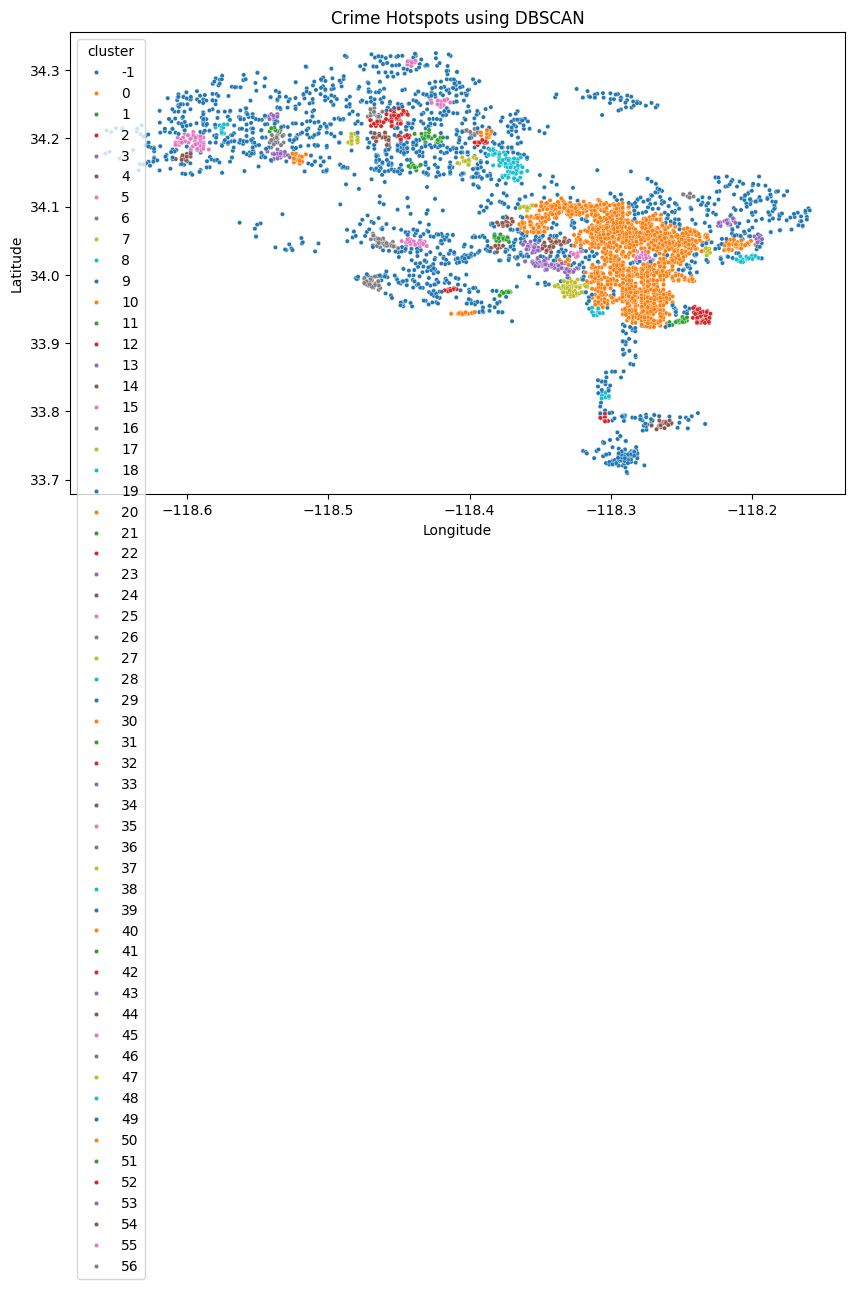

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['LON'],
    y=df['LAT'],
    hue=df['cluster'],
    palette='tab10',
    legend='full',
    s=10
)
plt.title("Crime Hotspots using DBSCAN")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

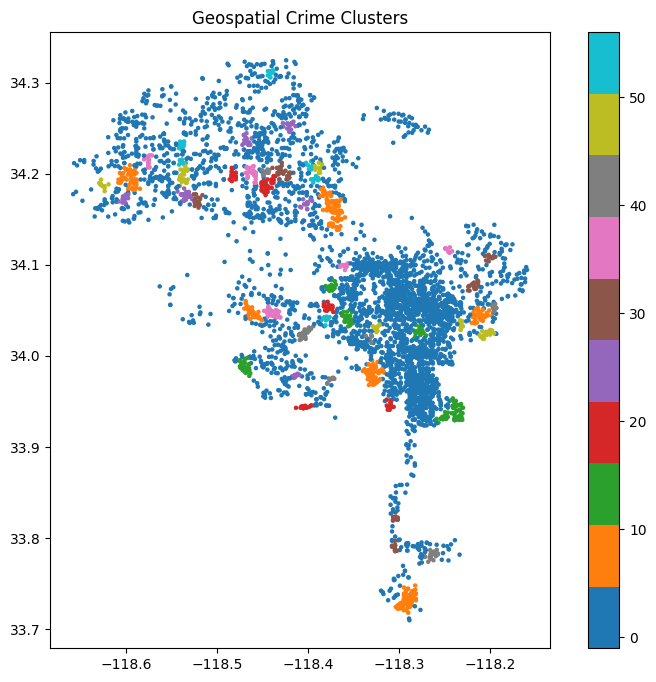

In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.LON, df.LAT)
)
gdf.plot(
    column='cluster',
    cmap='tab10',
    legend=True,
    figsize=(10, 8),
    markersize=5
)
plt.title("Geospatial Crime Clusters")
plt.show()